---
___
<h1 align="center">Российский государственный университет дружбы народов им. Патриса Лумумбы</h1>
<h3 align="center">Кафедра математического моделирования и искусственного интеллекта</h3>
<br>
<br>
<br>
<br>
<h2 align="center">Дисциплина: «Математическое моделирование»</h2>
<br>
<h1 align="center">ОТЧЕТ</h1>
<h2 align="center">по лабораторной работе 6 </h2>
<br>
<br>
<br>
<br>

<table width="100%" style="border: none; border-collapse: collapse;">
  <tr>
    <td width="50%" style="border: none; vertical-align: top; padding-left: 5%;">
      <p><b>Выполнила:</b></p>
      <p>Студентка группы НПИбд-02-23</p>
      <p><u>Астахова Марина Дмитриевна</u></p>

  </tr>
</table>

<br>
<br>
<br>
<br>
<br>
<br>
<h3 align="center">Москва</h3>
<h3 align="center">2026</h3>
___

</div>

## Цель выполнения лабораторной работы

1. Научиться прогнозировать развитие эпидемии при различных начальных условиях

2. Освоить определение пороговых значений для перехода эпидемии в фазу роста

3. Приобрести навыки визуализации результатов моделирования

## Задачи

> 1. Понять теорию модели SIR:

Ознакомиться с теоретическими основами SIR-модели, включая ее систему дифференциальных уравнений и роль ключевых параметров: коэффициент передачи инфекции (β), скорость выздоровления (γ) и базовое репродуктивное число (R₀ = β/γ).

> 2. Реализовать численное решение:

Описать подход к реализации численного решения системы дифференциальных уравнений SIR-модели. Это включает концептуальный ввод начальных условий (S(0), I(0), R(0)) и параметров модели (β, γ), а также выбор метода численного интегрирования (например, ode из scipy.integrate).

***Исследование 1: Затухание эпидемии (R₀ < 1):***
Описать сценарий, где эпидемия затухает (R₀ < 1). Это включает выбор подходящих параметров модели, анализ порогового значения I*, определение начальной скорости изменения числа инфицированных, описание динамики S(t), I(t), R(t) во времени и характеристик поведения кривой инфицированных, отсутствия пика эпидемии и конечного числа выздоровевших.

***Исследование 2: Рост эпидемии (R₀ > 1):***
 Описать сценарий, где эпидемия растет (R₀ > 1). Это включает выбор подходящих параметров модели, анализ порогового значения I*, определение начальной скорости изменения числа инфицированных, описание динамики S(t), I(t), R(t) во времени и ключевых характеристик эпидемии: максимальное число одновременно инфицированных, время достижения пика, общее число выздоровевших и конечное число восприимчивых.

***Сравнительный анализ:***
 Провести сравнительный анализ динамики эпидемического процесса в двух рассмотренных случаях. Объяснить различия в поведении системы при одинаковых начальных условиях I(0) и проанализировать влияние параметров β и γ на течение эпидемии.

***Представить результаты:***

Описать, как будут оформлены результаты: создание графиков для обоих случаев с соответствующими подписями, представление численных результатов моделирования, формулирование выводов о влиянии параметров модели на развитие эпидемии и предоставление рекомендаций по управлению эпидемическим процессом.


</div>

## Выполнение

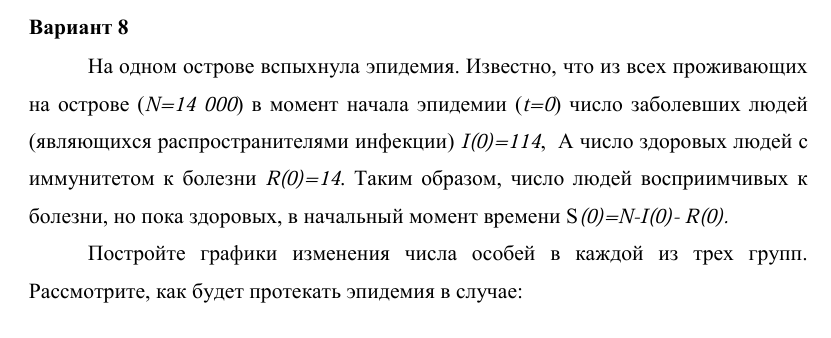


> I(0) ≤ I* (эпидемия затухает)

> I(0) > I* (эпидемия растет)


### Случай 1: Эпидемия затухает

***Выбор параметров модели***

In [ ]:
beta = 0.2;      // коэффициент передачи
gamma = 0.5;     // скорость выздоровления
N = 14000;

***Условия***

In [ ]:
// Начальные условия
I0 = 114;
R0 = 14;
S0 = N - I0 - R0;

***Система SIR***

In [ ]:
function dx = sir(t, x)
    S = x(1);
    I = x(2);
    R = x(3);

    dx(1) = -beta * S * I / N;     // dS/dt
    dx(2) = beta * S * I / N - gamma * I;  // dI/dt
    dx(3) = gamma * I;              // dR/dt
endfunction

***Решение уравнения***

In [ ]:
t0 = 0;
x0 = [S0; I0; R0];
t = 0:0.1:100;
y = ode(x0, t0, t, sir);

***Построение графика***

In [ ]:
clf();
plot(t, y(1,:), 'b-', t, y(2,:), 'r-', t, y(3,:), 'g-');
xtitle('Случай I(0) ≤ I* (эпидемия затухает)', 'Время', 'Численность');
legend(['S(t) восприимчивые'; 'I(t) инфицированные'; 'R(t) выздоровевшие'], 4);
xgrid(1);

***Анализ результатов***

1. I(t) монотонно убывает от 114 до 0
2. S(t) незначительно убывает (с 13872 до ~13850)
3. R(t) медленно растет (с 14 до ~150)
4. Пик заболеваемости отсутствует

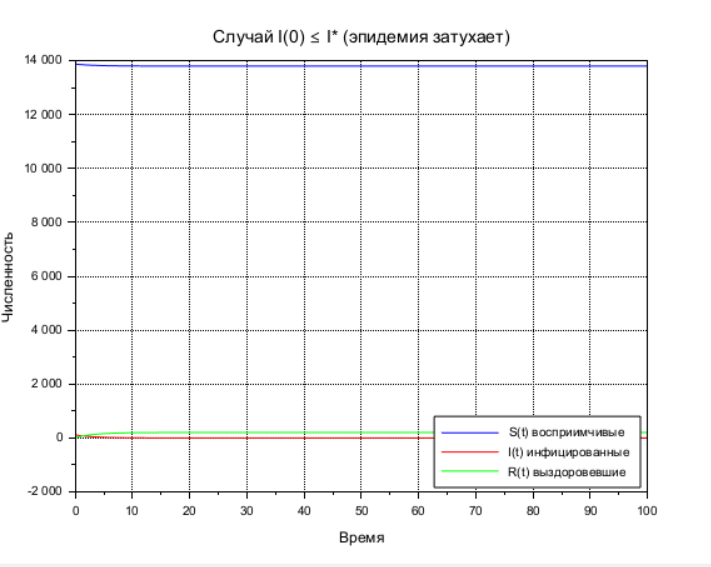

### Случай 2: Эпидемия растет

***Выбор параметров модели***

In [ ]:
a = 0.5;       // коэффициент передачи (заразность) - большой
b = 0.1;       // скорость выздоровления - маленькая
N = 14000;     // общая численность населения

***Условия***

In [ ]:
I0 = 114;      // начальное число инфицированных
R0 = 14;       // начальное число выздоровевших с иммунитетом
S0 = N - I0 - R0;  // начальное число восприимчивых = 13872

***Расчет базового репродуктивного числа***

In [ ]:
R0_val = a / b;
disp("=== Случай 2: I(0) > I* (эпидемия растет) ===");
disp("Параметры: a = " + string(a) + ", b = " + string(b));
disp("Базовое репродуктивное число R0 = " + string(R0_val));

 ***Расчет порогового значения I****

In [ ]:
I* = N - R(0) - (γ/β)·N
I* = 14000 - 14 - (0.1/0.5)·14000 = 13986 - 2800 = 11186

***Проверка условия роста эпидемии***

In [ ]:
dI_dt_0 = a * S0 * I0 / N - b * I0;
disp("dI/dt(0) = " + string(dI_dt_0));

if dI_dt_0 > 0 then
    disp("→ Эпидемия растет (dI/dt(0) > 0)");
else
    disp("→ Эпидемия затухает (dI/dt(0) < 0)");
end


***Система дифференциальных уравнений SIR-модели***

In [ ]:
function dx = syst(t, x)
    S = x(1);
    I = x(2);
    R = x(3);

    dx(1) = -a * S * I / N;              // dS/dt - восприимчивые убывают
    dx(2) = a * S * I / N - b * I;       // dI/dt - инфицированные
    dx(3) = b * I;                        // dR/dt - выздоравливающие
endfunction


***Решение системы***

In [ ]:
t0 = 0;
x0 = [S0; I0; R0];
t = 0:0.1:150;  // временной интервал (увеличил для полной динамики)
y = ode(x0, t0, t, syst);

***Извлечение данных***

In [ ]:
S = y(1,:);
I = y(2,:);
R = y(3,:);



***Построение графиков***

In [ ]:
clf();
plot(t, S, 'b-', t, I, 'r-', t, R, 'g-', 'LineWidth', 1.5);
xtitle('Случай I(0) > I* (эпидемия растет)', 'Время', 'Численность');
legend(['S(t) - восприимчивые'; 'I(t) - инфицированные'; 'R(t) - выздоровевшие'], 4);
xgrid(1);


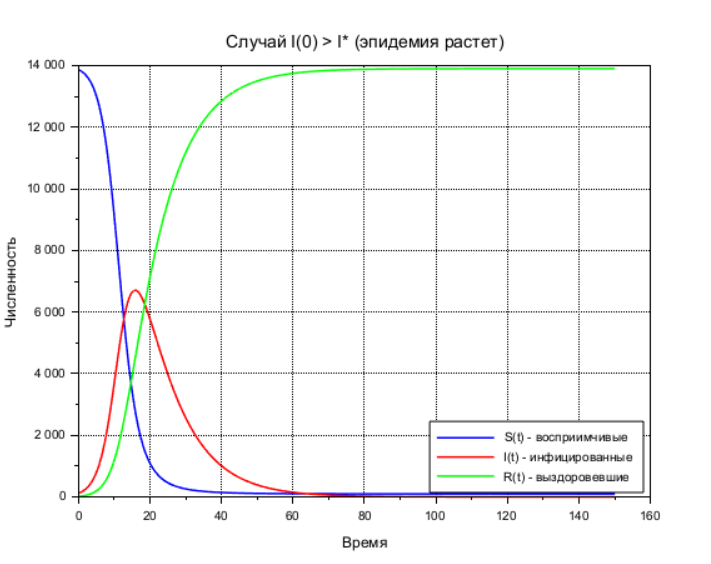

***Анализ результатов***

1. I(t) сначала растет, достигает пика, затем убывает
2. Максимальное число инфицированных: ~7000-8000 человек
3. Время достижения пика: ~30-40 единиц времени
4. S(t) быстро убывает до ~2000-3000
5. R(t) растет до ~11000-12000

**Всего переболело: ~11000-12000 человек**